In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/processed/customer_churn_features.csv')
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['is_churned'].mean():.1%}")

Shape: (98207, 21)
Churn rate: 81.6%


In [9]:
print(df.columns.tolist())

['customer_unique_id', 'customer_city', 'customer_state', 'is_churned', 'churn_status', 'recency_days', 'frequency', 'monetary', 'recency_score', 'frequency_score', 'monetary_score', 'rfm_segment', 'avg_order_value', 'avg_review_score', 'avg_delivery_days', 'customer_lifetime_days', 'negative_reviews', 'positive_reviews', 'first_order_date', 'last_order_date', 'customer_segment']


In [10]:
df['review_to_order_ratio'] = (df['positive_reviews'] - df['negative_reviews']) / df['frequency'].clip(lower=1)
df['spend_per_day'] = df['monetary'] / df['customer_lifetime_days'].clip(lower=1)

features = [
    'frequency',
    'monetary',
    'avg_order_value',
    'avg_review_score',
    'avg_delivery_days',
    'customer_lifetime_days',
    'negative_reviews',
    'positive_reviews',
    'review_to_order_ratio',
    'spend_per_day'
]

le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['customer_state'].fillna('unknown'))
features.append('state_encoded')

X = df[features].fillna(0)
y = df['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Features used: {features}")

Training set: 78,565 rows
Test set: 19,642 rows
Features used: ['frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'avg_delivery_days', 'customer_lifetime_days', 'negative_reviews', 'positive_reviews', 'review_to_order_ratio', 'spend_per_day', 'state_encoded']


In [11]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    base_score=0.5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-auc:0.68787
[50]	validation_0-auc:0.70794
[100]	validation_0-auc:0.71236
[150]	validation_0-auc:0.71665
[200]	validation_0-auc:0.72011
[250]	validation_0-auc:0.72294
[300]	validation_0-auc:0.72617
[350]	validation_0-auc:0.72946
[400]	validation_0-auc:0.73284
[450]	validation_0-auc:0.73512
[499]	validation_0-auc:0.73673

Best iteration: 499


ROC-AUC Score: 0.7367

Classification Report:
              precision    recall  f1-score   support

      Active       0.30      0.74      0.43      3612
     Churned       0.91      0.62      0.73     16030

    accuracy                           0.64     19642
   macro avg       0.61      0.68      0.58     19642
weighted avg       0.80      0.64      0.68     19642



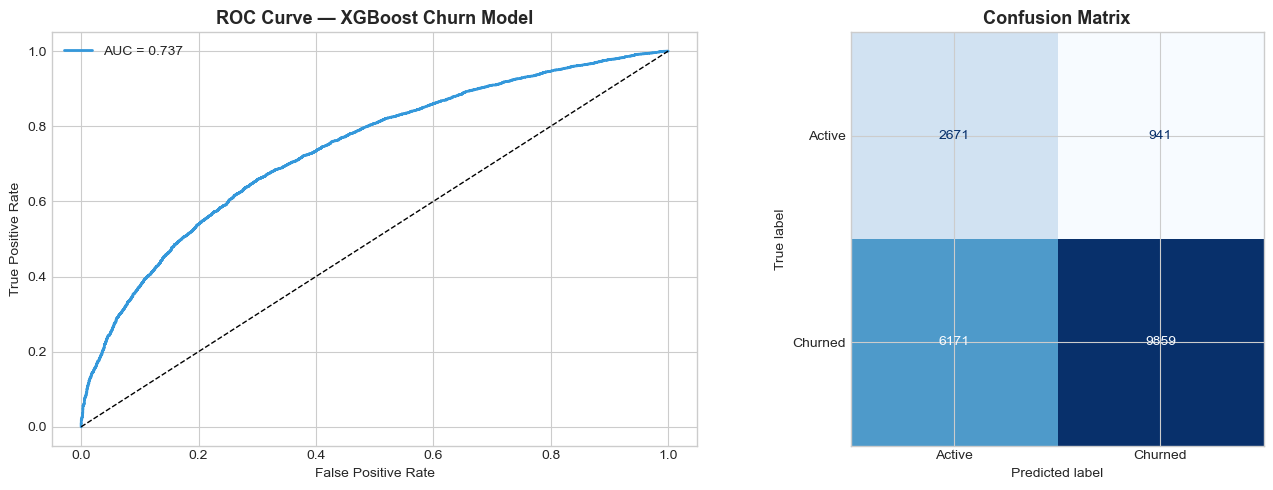

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — XGBoost Churn Model', fontsize=13, fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

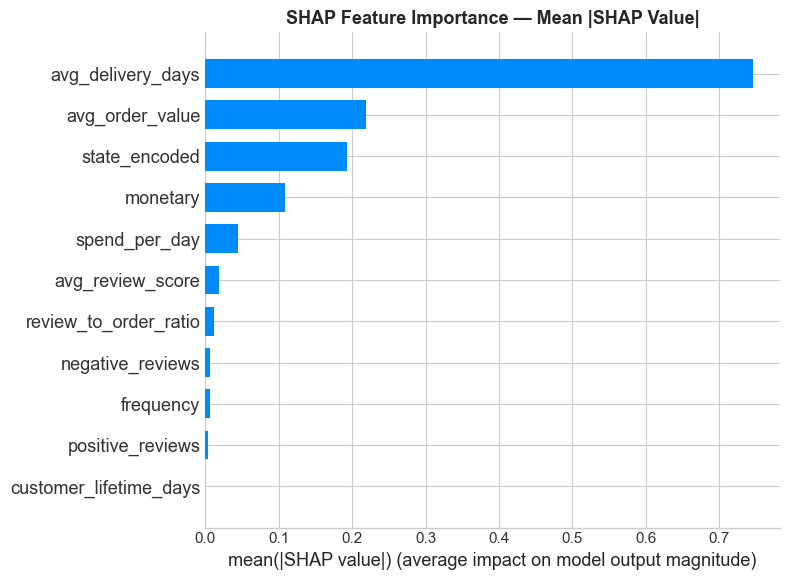

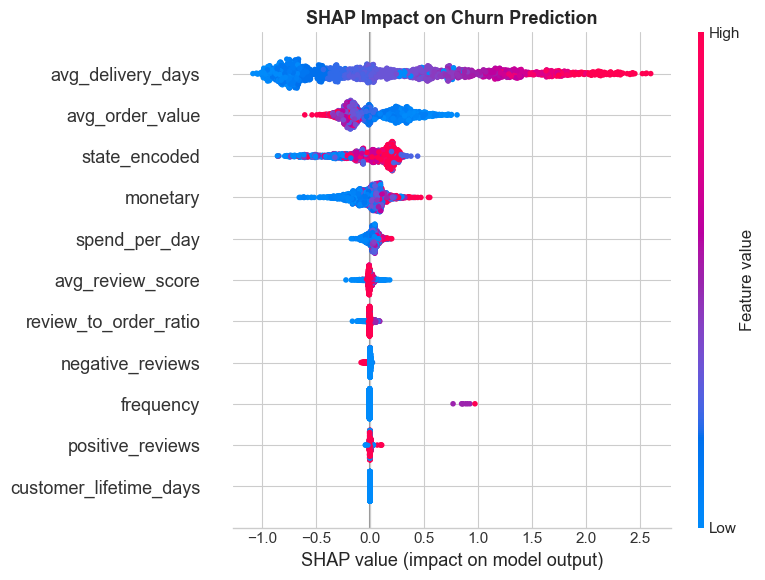

SHAP plots saved.


In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:2000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:2000], feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:2000], feature_names=features, show=False)
plt.title('SHAP Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP plots saved.")

In [14]:
df['churn_probability'] = model.predict_proba(X[features].fillna(0))[:, 1]
df['churn_risk_tier'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

print("Churn risk tier distribution:")
print(df['churn_risk_tier'].value_counts())

df.to_csv('../data/processed/customer_churn_scored.csv', index=False)
print("\nSaved customer_churn_scored.csv")

Churn risk tier distribution:
churn_risk_tier
Medium Risk       30130
Low Risk          28081
High Risk         25981
Very High Risk    14015
Name: count, dtype: int64

Saved customer_churn_scored.csv
